In [2]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import pickle

# For XGBoost
try:
    import xgboost as xgb
except ImportError:
    print("XGBoost not installed. Install with: pip install xgboost")

# Set random seed for reproducibility
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

print("Libraries successfully imported.")

Libraries successfully imported.


In [3]:
# Define path for feature-engineered data
data_dir = '../data'
input_file = os.path.join(data_dir, 'flights_features_v1.csv')

# Load the data
print(f"Loading feature-engineered data from: {input_file}")
df_model = pd.read_csv(input_file)

# Separate features and target
target_col = 'IS_DELAYED'
X = df_model.drop(columns=[target_col])
y = df_model[target_col]

print(f"Data loaded successfully with {X.shape[0]:,} rows and {X.shape[1]:,} features.")
print(f"Target distribution: {y.value_counts(normalize=True).to_dict()}")

Loading feature-engineered data from: ../data\flights_features_v1.csv
Data loaded successfully with 2,913,802 rows and 35 features.
Target distribution: {0: 0.8231557943882254, 1: 0.17684420561177458}


In [5]:
# Option 1: Load saved model if you saved it in notebook 04
model_path = '../models/flight_delay_model.pkl'

if os.path.exists(model_path):
    print(f"Loading saved XGBoost model from: {model_path}")
    with open(model_path, 'rb') as f:
        xgb_model = pickle.load(f)
    print("Model loaded successfully.")
else:
    print(f"Saved model not found at {model_path}. Retraining XGBoost model...")
    
    # Recreate the train-test split
    mask_2023 = X['YEAR'] == 2023
    X_train = X[~mask_2023]
    y_train = y[~mask_2023]
    X_test = X[mask_2023]
    y_test = y[mask_2023]
    
    # Calculate class weights
    from sklearn.utils.class_weight import compute_class_weight
    class_weights = compute_class_weight('balanced', classes=np.array([0, 1]), y=y_train)
    weight_dict = {0: class_weights[0], 1: class_weights[1]}
    sample_weights = np.array([weight_dict[y_val] for y_val in y_train])
    
    # Train the model
    xgb_model = xgb.XGBClassifier(
        n_estimators=100,
        learning_rate=0.1,
        max_depth=5,
        random_state=RANDOM_SEED,
        n_jobs=-1
    )
    
    xgb_model.fit(X_train, y_train, sample_weight=sample_weights)
    print("XGBoost model trained successfully.")
    
    # Save the model for future use
    os.makedirs('../models', exist_ok=True)
    with open(model_path, 'wb') as f:
        pickle.dump(xgb_model, f)
    print(f"Model saved to {model_path}")

Saved model not found at ../models/flight_delay_model.pkl. Retraining XGBoost model...
XGBoost model trained successfully.
Model saved to ../models/flight_delay_model.pkl


In [5]:
# More Memory-Efficient Hyperparameter Tuning
print("Starting reduced hyperparameter tuning for XGBoost model...")

from sklearn.model_selection import RandomizedSearchCV  # Use randomized instead of grid

# Take a sample of data for tuning (adjust sample size based on your memory)
sample_size = 100000  # Use 100K rows instead of millions
sample_indices = np.random.choice(len(X_train), size=min(sample_size, len(X_train)), replace=False)
X_train_sample = X_train.iloc[sample_indices]
y_train_sample = y_train.iloc[sample_indices]
sample_weights_sample = sample_weights[sample_indices]

# Simplified parameter grid with fewer combinations
param_grid = {
    'max_depth': [3, 5],
    'learning_rate': [0.05, 0.1],
    'n_estimators': [100, 150],
    'min_child_weight': [1, 3]
}

# Create a base model
base_model = xgb.XGBClassifier(random_state=RANDOM_SEED, n_jobs=-1)

# Use RandomizedSearchCV instead (tests fewer combinations)
random_search = RandomizedSearchCV(
    estimator=base_model,
    param_distributions=param_grid,
    n_iter=8,  # Try only 8 combinations instead of all 16
    scoring='f1',
    cv=3,
    n_jobs=1,  # Use single job to reduce memory usage
    verbose=1
)

# Fit on the sample
print("Training models with different hyperparameters on data sample...")
random_search.fit(X_train_sample, y_train_sample, sample_weight=sample_weights_sample)

# Show best parameters and score
print(f"Best parameters: {random_search.best_params_}")
print(f"Best F1 score on sample: {random_search.best_score_:.4f}")

# Train final model with best parameters on full dataset
print("Training final model with best parameters on full dataset...")
best_model = xgb.XGBClassifier(
    **random_search.best_params_,
    random_state=RANDOM_SEED
)
best_model.fit(X_train, y_train, sample_weight=sample_weights)

# Evaluate on test set
y_pred_best = best_model.predict(X_test)
from sklearn.metrics import classification_report, accuracy_score, f1_score
print("\nTest Set Performance:")
print(f"Accuracy: {accuracy_score(y_test, y_pred_best):.4f}")
print(f"F1 Score: {f1_score(y_test, y_pred_best):.4f}")
print(classification_report(y_test, y_pred_best))

# Save the improved model
improved_model_path = '../models/flight_delay_model_tuned.pkl'
with open(improved_model_path, 'wb') as f:
    pickle.dump(best_model, f)
print(f"Improved model saved to {improved_model_path}")

Starting reduced hyperparameter tuning for XGBoost model...
Training models with different hyperparameters on data sample...
Fitting 3 folds for each of 8 candidates, totalling 24 fits
Best parameters: {'n_estimators': 150, 'min_child_weight': 1, 'max_depth': 5, 'learning_rate': 0.05}
Best F1 score on sample: 0.3635
Training final model with best parameters on full dataset...

Test Set Performance:
Accuracy: 0.5178
F1 Score: 0.4110
              precision    recall  f1-score   support

           0       0.86      0.45      0.59    353119
           1       0.28      0.75      0.41    101294

    accuracy                           0.52    454413
   macro avg       0.57      0.60      0.50    454413
weighted avg       0.73      0.52      0.55    454413

Improved model saved to ../models/flight_delay_model_tuned.pkl


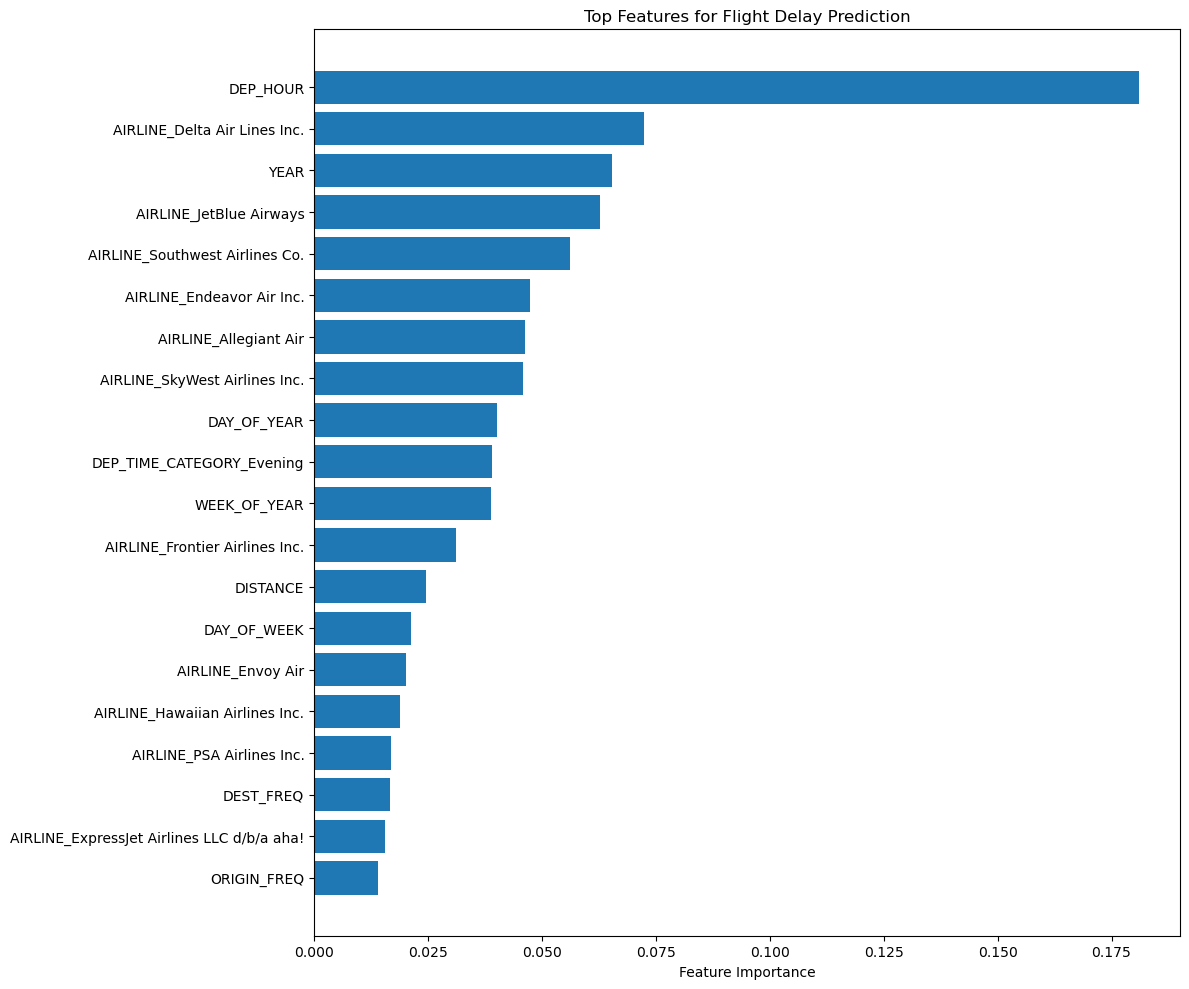

Top 10 Most Important Features:
1. DEP_HOUR: 0.1810
2. AIRLINE_Delta Air Lines Inc.: 0.0724
3. YEAR: 0.0653
4. AIRLINE_JetBlue Airways: 0.0627
5. AIRLINE_Southwest Airlines Co.: 0.0562
6. AIRLINE_Endeavor Air Inc.: 0.0474
7. AIRLINE_Allegiant Air: 0.0462
8. AIRLINE_SkyWest Airlines Inc.: 0.0457
9. DAY_OF_YEAR: 0.0402
10. DEP_TIME_CATEGORY_Evening: 0.0391


In [6]:
# Create a feature importance plot
plt.figure(figsize=(12, 10))

# Get feature importance from the model
feature_importance = xgb_model.feature_importances_
# Sort features by importance
sorted_idx = np.argsort(feature_importance)
# Get feature names
features = X.columns

# Plot the top 20 most important features (or all if fewer than 20)
top_n = min(20, len(features))
plt.barh(range(top_n), feature_importance[sorted_idx[-top_n:]])
plt.yticks(range(top_n), [features[i] for i in sorted_idx[-top_n:]])
plt.xlabel('Feature Importance')
plt.title('Top Features for Flight Delay Prediction')
plt.tight_layout()
plt.show()

# Print the top 10 most important features
print("Top 10 Most Important Features:")
top_indices = sorted_idx[-10:][::-1]
for i, idx in enumerate(top_indices):
    print(f"{i+1}. {features[idx]}: {feature_importance[idx]:.4f}")